<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/02.circuits-and-encoding/03.ansatz-and-parameterized-circuits/day18_03_01_pennylane_strongly_entangling_classifier_training_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day18 StronglyEntanglingLayers 실습

- Source: Google Drive `Day18/3-1.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Environment
Qubits : 4
STEP 2. Dataset
Samples : 80
STEP 5. Training


Epoch 01 Loss : 2.2178


Epoch 02 Loss : 2.1191


Epoch 03 Loss : 2.0060


Epoch 04 Loss : 1.8833


...

Epoch 26 Loss : 0.4317


Epoch 27 Loss : 0.3931


Epoch 28 Loss : 0.3601


Epoch 29 Loss : 0.3336


Epoch 30 Loss : 0.3138
STEP 6. Evaluation
Accuracy : 0.9375
Confusion Matrix
[[7 1]
 [0 8]]
STEP 7. Circuit
0: ─╭AngleEmbedding(M0)──Rot(0.03,0.45,0.13)────╭●───────╭X──Rot(0.04,-0.01,-0.02)─╭●───────╭X─┤ ···
1: ─├AngleEmbedding(M0)──Rot(-0.82,1.44,0.05)───╰X─╭●────│───Rot(0.40,1.07,-0.00)──╰X─╭●────│──┤ ···
2: ─├AngleEmbedding(M0)──Rot(0.89,0.69,-0.88)──────╰X─╭●─│───Rot(1.37,-0.64,-0.14)────╰X─╭●─│──┤ ···
3: ─╰AngleEmbedding(M0)──Rot(-0.36,-1.33,-1.03)───────╰X─╰●──Rot(1.29,0.69,0.04)─────────╰X─╰●─┤ ···

0: ···   <Z>
1: ···      
2: ···      
3: ···      

M0 = 
[2.95764112 2.34668841 1.79513617 2.87807265]


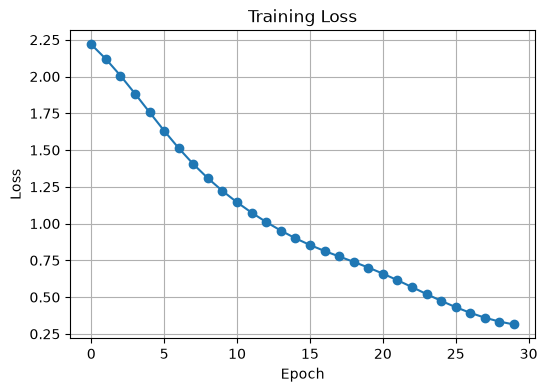

In [1]:

"""
==========================================================
Lab. Strongly Entangling Layer 구현 실습
==========================================================
"""

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ==========================================================
# STEP 1. Environment
# ==========================================================
np.random.seed(42)

N_QUBITS = 4
N_LAYERS = 2
EPOCHS = 30

dev = qml.device("default.qubit", wires=N_QUBITS)

print("="*70)
print("STEP 1. Environment")
print("="*70)
print(f"Qubits : {N_QUBITS}")

# ==========================================================
# STEP 2. Dataset
# ==========================================================
normal = np.random.normal(
    loc=[60,0.2,5,12],
    scale=[3,0.05,0.4,1],
    size=(40,4)
)

fault = np.random.normal(
    loc=[80,0.7,7,18],
    scale=[3,0.05,0.5,1],
    size=(40,4)
)

X = np.vstack([normal,fault])
y = np.hstack([np.full(40,-1),np.full(40,1)])

print("="*70)
print("STEP 2. Dataset")
print("="*70)
print("Samples :",len(X))

# ==========================================================
# STEP 3. Normalize
# ==========================================================
scaler = MinMaxScaler(feature_range=(0,np.pi))
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

# ==========================================================
# STEP 4. Layers
# ==========================================================
def rotation_layer(weights):
    for i in range(N_QUBITS):
        qml.Rot(*weights[i], wires=i)

def entanglement_layer():
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i,(i+1)%N_QUBITS])

@qml.qnode(dev)
def circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation="Y")
    for l in range(N_LAYERS):
        rotation_layer(weights[l])
        entanglement_layer()
    return qml.expval(qml.PauliZ(0))

weights = np.random.normal(0,0.1,(N_LAYERS,N_QUBITS,3), requires_grad=True)

def loss(w):
    preds = np.array([circuit(x,w) for x in X_train])
    return np.mean((preds-y_train)**2)

opt = qml.AdamOptimizer(stepsize=0.05)
history=[]

print("="*70)
print("STEP 5. Training")
print("="*70)

for epoch in range(EPOCHS):
    weights = opt.step(loss, weights)
    l = loss(weights)
    history.append(l)
    print(f"Epoch {epoch+1:02d} Loss : {l:.4f}")

pred = np.array([1 if circuit(x,weights)>=0 else -1 for x in X_test])

acc = accuracy_score(y_test,pred)

print("="*70)
print("STEP 6. Evaluation")
print("="*70)
print("Accuracy :",round(acc,4))
print("Confusion Matrix")
print(confusion_matrix(y_test,pred))

print("="*70)
print("STEP 7. Circuit")
print("="*70)
print(qml.draw(circuit)(X_train[0],weights))

plt.figure(figsize=(6,4))
plt.plot(history,marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

